# Baseline Model Evaluation

This notebook evaluates the trained Wav2Vec2 dementia speech classification model on the held out test dataset.

The test dataset was not used during model training or validation and therefore provides an unbiased estimate of model performance.

The evaluation pipeline performs the following steps:

* load the trained model and processor from the HuggingFace Hub  
* reconstruct deterministic audio segments from the test dataset manifests  
* generate predictions for each test sample  
* compute evaluation metrics including accuracy, precision, recall, and macro F1 score  
* visualize results using a confusion matrix and class level performance plots  

These analyses provide insight into how well the model distinguishes between dementia and non dementia speech patterns.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys

PROJECT_DIR = "/content/drive/MyDrive/CS7357_Project/data"
sys.path.append(PROJECT_DIR)

from config import *

In [ ]:
import pandas as pd

test_df = pd.read_csv(TEST_MANIFEST, sep="\t")
print("Test samples:", len(test_df))

Test samples: 38


In [ ]:
label_map = {
    "nodementia": 0,
    "dementia": 1
}

test_df["label"] = test_df["label"].map(label_map)

In [ ]:
import torch
import torchaudio

def load_audio_segment(row):
    path = row["path"]
    start = row["start_sec"]
    clip = row["clip_sec"]

    sr = 16000

    frame_offset = int(start * sr)
    num_frames = int(clip * sr)

    waveform, _ = torchaudio.load(
        path,
        frame_offset=frame_offset,
        num_frames=num_frames
    )

    return waveform.squeeze().numpy()

In [ ]:
from datasets import Dataset

test_dataset = Dataset.from_pandas(test_df)

### Load the audio processor used during model training.
 The processor converts raw waveform audio into normalized
 input tensors expected by the Wav2Vec2 model.

In [ ]:
from transformers import Wav2Vec2Processor

processor = Wav2Vec2Processor.from_pretrained(
    "Mrsmetamorphosis/dementia-wav2vec-scientific-baseline"
)

### Preprocess
 Preprocess the test dataset by converting audio segments
 into model compatible input tensors using the Wav2Vec2 processor.

In [ ]:
def preprocess(batch):

    audio = load_audio_segment(batch)

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    batch["input_values"] = inputs.input_values[0]
    batch["labels"] = batch["label"]

    return batch

test_dataset = test_dataset.map(preprocess)

Map:   0%|          | 0/38 [00:00<?, ? examples/s]

### Load the Trained Baseline

 Load the trained baseline classification model from HuggingFace.
 The model has been fine tuned to classify dementia vs non dementia speech.

In [ ]:
from transformers import Wav2Vec2ForSequenceClassification

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "Mrsmetamorphosis/dementia-wav2vec-scientific-baseline"
)

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

### Initialize the HuggingFace Trainer for inference.
 This allows us to generate predictions using the trained model.

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model
)

### Run model
Run the model inference on the held out test dataset
 and convert output logits into predicted class labels.

In [ ]:
pred = trainer.predict(test_dataset)

preds = pred.predictions.argmax(axis=1)
labels = pred.label_ids

### Compute evaluation metrics

Now we need to compute the eval metrics to quantify model performance.

 Macro averaging treats both classes equally regardless of dataset imbalance.

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    labels, preds, average="macro"
)

accuracy = accuracy_score(labels, preds)

print("Accuracy:", accuracy)
print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1:", f1)

Accuracy: 0.3157894736842105
Macro Precision: 0.34294871794871795
Macro Recall: 0.3541666666666667
Macro F1: 0.3138888888888889


###Confusion Matrix
 Visualize prediction outcomes using a confusion matrix
 to examine correct and incorrect classifications.

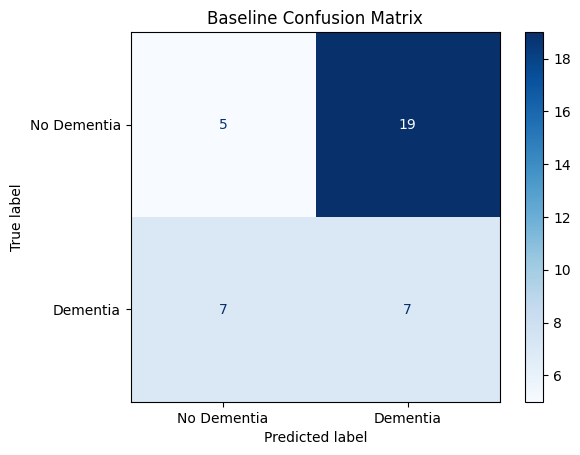

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

pred = trainer.predict(test_dataset)

preds = np.argmax(pred.predictions, axis=1)
labels = pred.label_ids

cm = confusion_matrix(labels, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Dementia", "Dementia"]
)

disp.plot(cmap="Blues")

plt.title("Baseline Confusion Matrix")
plt.show()

## Evaluate Model on Test Dataset

After training completes, the model is evaluated on the held out test dataset.

In [ ]:
results = trainer.evaluate(test_dataset)

print(results)

{'eval_loss': 3.9141030311584473, 'eval_model_preparation_time': 0.0014, 'eval_runtime': 4.6309, 'eval_samples_per_second': 8.206, 'eval_steps_per_second': 1.08}


### F1 Bar Chart
 Plot class specific F1 scores to analyze model performance
 for dementia and non dementia speech independently.

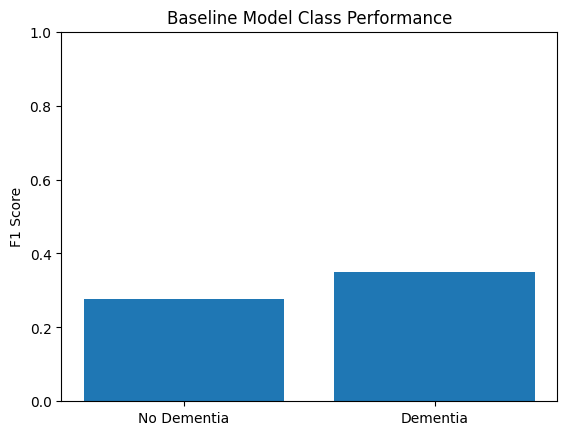

In [ ]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Compute class specific F1 scores
f1_no = f1_score(labels, preds, pos_label=0)
f1_dem = f1_score(labels, preds, pos_label=1)

f1_scores = [f1_no, f1_dem]

labels_names = ["No Dementia", "Dementia"]

plt.figure()
plt.bar(labels_names, f1_scores)

plt.title("Baseline Model Class Performance")
plt.ylabel("F1 Score")
plt.ylim(0,1)

plt.show()

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score
)

y_true = true_labels.values
y_pred = recording_preds["prediction"].values
y_prob = recording_preds["prob_dem"].values

print("Number of recordings:", len(y_true))

print("\nBalanced Accuracy:")
print(balanced_accuracy_score(y_true, y_pred))

print("\nROC AUC:")
print(roc_auc_score(y_true, y_prob))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

NameError: name 'true_labels' is not defined